# Linear SVM Classification.

In [1]:
import matplotlib.pyplot as plt

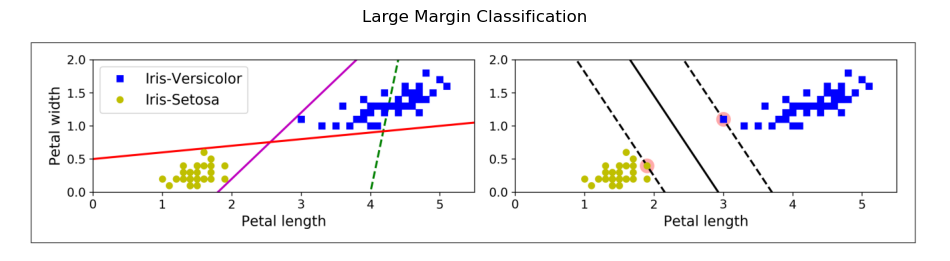

In [2]:
plt.figure(figsize=(12,8))
img=plt.imread("Screenshot 2025-03-27 163504.png")
plt.axis('off')
plt.title("Large Margin Classification")
plt.imshow(img)


- The two classes in the dataset can be separated using a straight line, meaning they are linearly separable.
- The left plot shows three different decision boundaries, where the dashed line do not separate the classes well, while others fit too closely to the training data.
- Decision boundaries that are too close to the data points may perform well on the training set but can generalize poorly to new instances.
- SVM aims to find the decision boundary that maximizes the distance (margin) between the closest training points (support vectors) from both classes.
- The solid line in the right plot represents the SVM classifier, which finds the widest possible "street" (margin) while still correctly classifying the data.


    <p style="font-weight:bold;text-align:center;">"SVM is sensitive to the Scale of the Features"</p>
    
* In SVM the marginal distance is calculated as $$d=\frac{2}{||W||} $$ 
* Now the objective is to maximize the marginal distance

# Hard Margin SVM:

$$ \text{Objective function}= minimize: \frac{1}{2}{||W||}^2 \: \text  {subjected to} \:{y_i}(W^T+b)\geq{1}\: \forall i. $$ 

# Soft Margin SVM:
$$ \text{Objective Function} = minimize: \frac{1}{2}{||W||}^2 + C\sum_{i=1}^n{\zeta_i} $$
$$ Loss = \text{Margin Error} + \text{Classification Error} $$
* Here minimizing ||W||  is maximizing d 

In [3]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [4]:
iris=datasets.load_iris()

In [5]:
X=iris['data'][:,[2,3]]# petal length and petal width
y=(iris['target']==2).astype(np.int32) # Iris Virginica

In [6]:
svm_clf=Pipeline(
    
    [('scaler',StandardScaler()),
     ('linear_svc',LinearSVC(C=1,loss='hinge'))
    ]
)
svm_clf.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [7]:
svm_clf.predict([[5.5,1.7]])

array([1])

# Non Linear SVM

In [1]:
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [3]:
X,y=make_moons(n_samples=200,noise=0.1,random_state=42)

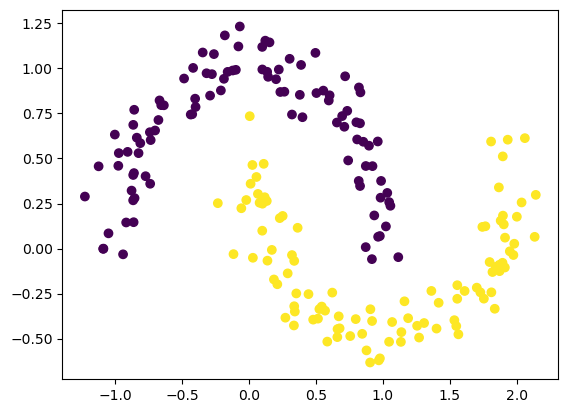

In [10]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
model=Pipeline(
    [('poly_features',PolynomialFeatures(degree=2)),
     ('svm_clf',SVC(kernel='rbf',C=10))
    ]
)

In [8]:
model.fit(X,y)

Pipeline(steps=[('poly_features', PolynomialFeatures()),
                ('svm_clf', SVC(C=10))])

In [16]:
model.name_steps['poly_features']


AttributeError: 'Pipeline' object has no attribute 'name_steps'

In [17]:
import numpy as np

In [20]:
def plot_decision_boundary(model, X, y):
    X1_min, X1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    X2_min, X2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    X1X1, X2X2 = np.meshgrid(np.linspace(X1_min, X1_max, 200),
                             np.linspace(X2_min, X2_max, 200))
    
    Z = model.predict(np.c_[X1X1.ravel(), X2X2.ravel()])
    Z = Z.reshape(X1X1.shape)
    
    plt.contourf(X1X1, X2X2, Z, alpha=0.3, cmap='coolwarm')
    plt.contour(X1X1, X2X2, Z, colors='green', linewidths=1)
    
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], marker='s', color='blue', label='Class 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='^', color='green', label='Class 1')

    plt.xlabel("$X_1$", fontsize=14)
    plt.ylabel("$X_2$", fontsize=14)
    plt.legend()
    plt.title("Linear SVM Classifier using Polynomial Features")
    plt.show()


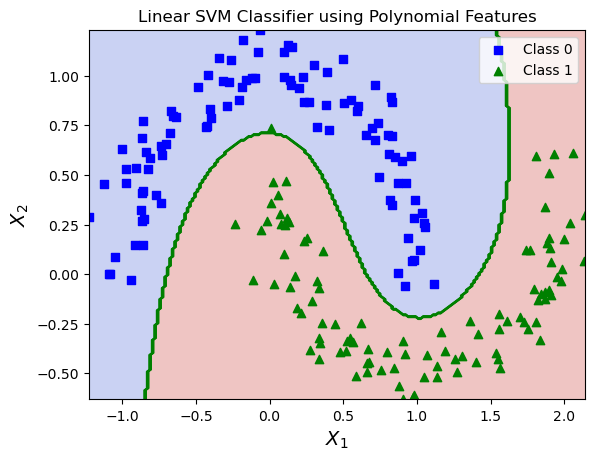

In [21]:
plot_decision_boundary(model,X,y)

   # Polynomial Kernel

In [270]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

In [4]:
X,y=make_moons(n_samples=200, noise=0.1,random_state=42)

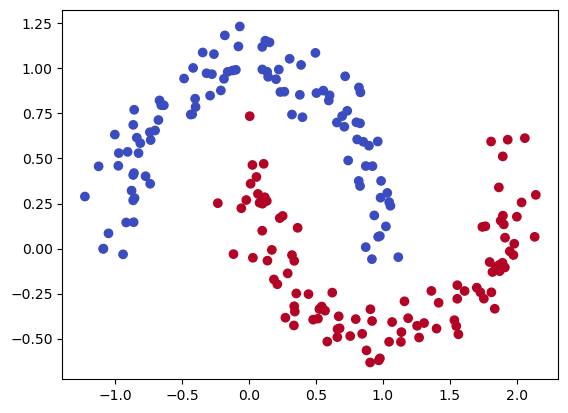

In [7]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')

In [101]:
poly_kernel_svm_clf=Pipeline([
    ('scaler',StandardScaler()),
    ('svm_clf',SVC(kernel='poly',C=1,degree=5,coef0=1))
])

In [108]:
poly_kernel_svm_clf_2=Pipeline([
    ('scaler',StandardScaler()),
    ('svm_clf',SVC(kernel='poly',C=1,degree=10,coef0=1))
])

In [109]:
poly_kernel_svm_clf.fit(X,y)
poly_kernel_svm_clf_2.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=1, coef0=1, degree=10, kernel='poly'))])

In [110]:
def plot_decision_boundary(model,X,y,ax=None,title=None):
    X1_min,X1_max=X[:,0].min()-1,X[:,0].max()+1
    X2_min,X2_max=X[:,1].min()-1,X[:,1].max()+1
    
    X1=np.linspace(X1_min,X1_max,num=200)
    X2=np.linspace(X2_min,X2_max,num=200)
    
    X1X1,X2X2=np.meshgrid(X1,X2)
    Z=np.concatenate((X1X1.ravel().reshape(-1,1),X2X2.ravel().reshape(-1,1)),axis=1)
    
    
    Z=model.predict(Z).reshape(X1X1.shape)
    ax.contour(X1X1,X2X2,Z)
    ax.contourf(X1X1,X2X2,Z,cmap='coolwarm',alpha=0.1)
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], marker='s', color='blue', label='Class 0')
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='^', color='green', label='Class 1')
    
    ax.set_xlabel("$X_1$", fontsize=14)
    ax.set_ylabel("$X_2$", fontsize=14)
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    

C:\Users\jrgau\AppData\Local\Temp\ipykernel_4624\4283926029.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


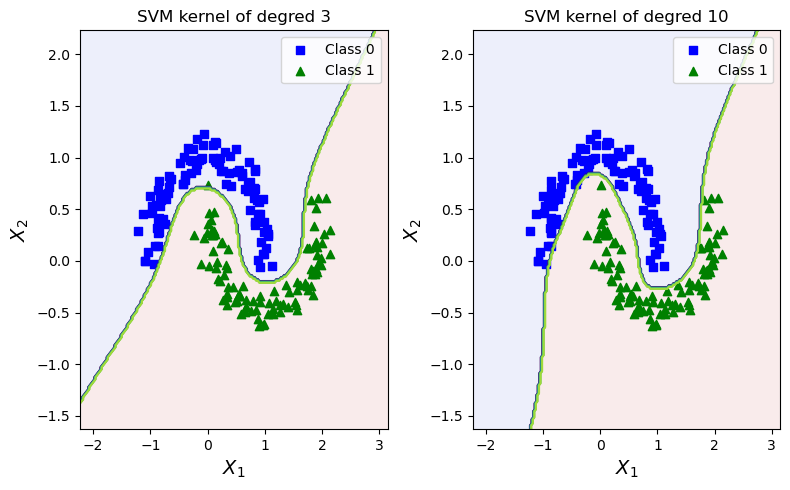

In [111]:
fig,axes=plt.subplots(1,2,figsize=(8,5))
plot_decision_boundary(poly_kernel_svm_clf,X,y,axes[0],title=f"SVM kernel of degred 3")
plot_decision_boundary(poly_kernel_svm_clf_2,X,y,axes[1],title=f"SVM kernel of degred 10")

`Key Observations`
1. The SVm model with polynomial degree 3 is seems more balanced where the decision boundary is not more peaked.
2. While polynomial degree 10 the model is hardly trying to classify the each data points to correct class which is leading to more peaked decision boundary and seems overfitting.

In [113]:
from sklearn.datasets import make_classification

In [185]:
X, y = make_classification(n_samples=10,
                           n_features=2,
                           n_informative=1,
                           n_redundant=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           random_state=42)


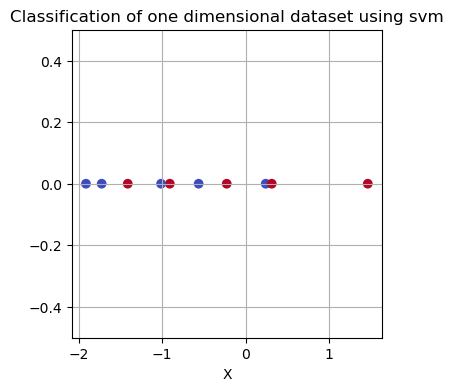

In [186]:
plt.figure(figsize=(4,4))
plt.scatter(X[:,0], [0]*len(X[:,0]),c=y,cmap='coolwarm')
plt.xlabel('X')
plt.title("Classification of one dimensional dataset using svm")
plt.ylim(-0.5,0.5)
plt.grid()
plt.show()


## Radial Basis Function
 ## $$ \phi_{\gamma}{(x,l)}=e^{\gamma*{||x-l||^2}} $$

In [266]:


def plot_rbf(x, y):
    gamma = 1
    landmark1 = -3
    landmark2 = 2
    
    # Correct element-wise RBF calculation
    rbf1 = np.exp(-gamma * np.abs(x - landmark1)**2)  # Using abs for clarity
    rbf2 = np.exp(-gamma * np.abs(x - landmark2)**2)

    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].plot(x, rbf1, label=f'RBF at {landmark1}', color='red')
    ax[0].plot(x, rbf2, label=f'RBF at {landmark2}', color='blue')
    
    ax[0].scatter(x, np.zeros_like(x), c=y)
    ax[1].scatter(rbf1, rbf2, c=y)
    
    ax[0].set_title("Gaussian RBF Similarity")
    ax[0].legend()
    plt.tight_layout()
    plt.show()

# Generate proper input data


RBF1 shape: (9,) values: [3.67879441e-01 1.00000000e+00 3.67879441e-01 1.83156389e-02
 1.23409804e-04 1.12535175e-07 1.38879439e-11 2.31952283e-16
 5.24288566e-22]
RBF2 shape: (9,) values: [2.31952283e-16 1.38879439e-11 1.12535175e-07 1.23409804e-04
 1.83156389e-02 3.67879441e-01 1.00000000e+00 3.67879441e-01
 1.83156389e-02]


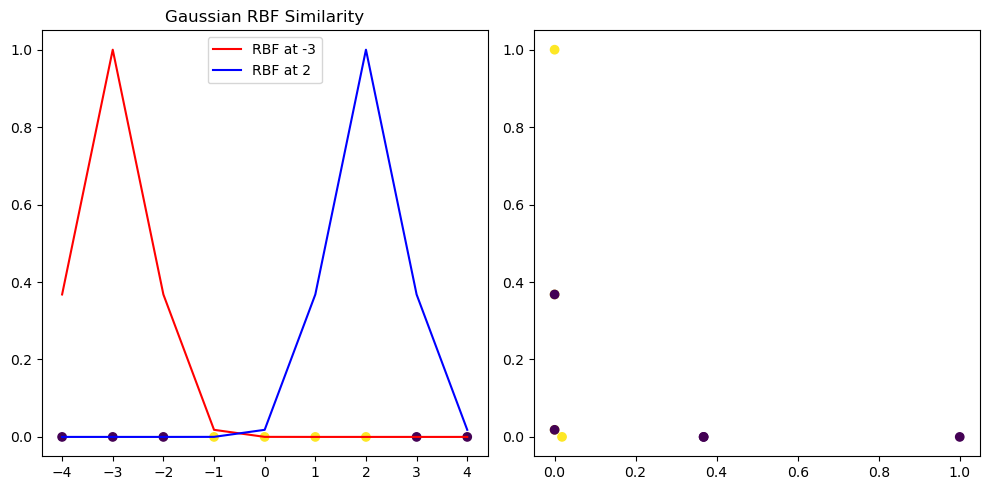

In [267]:
X = np.linspace(-4, 4, 11)  # As 1D vector
X=np.array([-4,-3,-2,-1,0,1,2,3,4])
y = [0,0,0,1,1,1,1,0,0]

plot_rbf(X, y)

# RBF kernel

In [268]:
def plot_decision_boundary(model,X,y,ax=None,title=None):
    X1_min,X1_max=X[:,0].min()-1,X[:,0].max()+1
    X2_min,X2_max=X[:,1].min()-1,X[:,1].max()+1
    
    X1=np.linspace(X1_min,X1_max,num=200)
    X2=np.linspace(X2_min,X2_max,num=200)
    
    X1X1,X2X2=np.meshgrid(X1,X2)
    Z=np.concatenate((X1X1.ravel().reshape(-1,1),X2X2.ravel().reshape(-1,1)),axis=1)
    
    
    Z=model.predict(Z).reshape(X1X1.shape)
    ax.contour(X1X1,X2X2,Z)
    ax.contourf(X1X1,X2X2,Z,cmap='coolwarm',alpha=0.1)
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], marker='s', color='blue', label='Class 0')
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='^', color='green', label='Class 1')
    
    ax.set_xlabel("$X_1$", fontsize=14)
    ax.set_ylabel("$X_2$", fontsize=14)
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    

In [271]:
X,y=make_moons(n_samples=200, noise=0.1,random_state=42)

In [269]:
gamma=[0.1,5]
C=[0.001,1000]

C:\Users\jrgau\AppData\Local\Temp\ipykernel_4624\4283926029.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\jrgau\AppData\Local\Temp\ipykernel_4624\4283926029.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\jrgau\AppData\Local\Temp\ipykernel_4624\4283926029.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


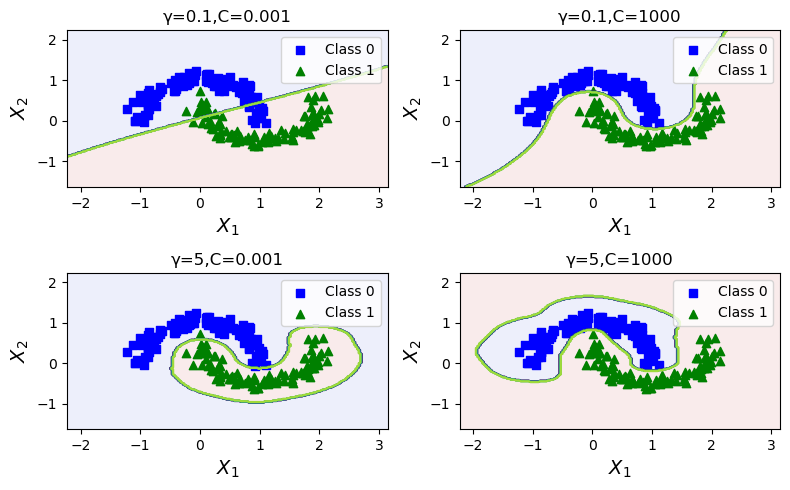

In [277]:
fig,ax=plt.subplots(2,2,figsize=(8,5))
for i,g in enumerate(gamma):
    for j,c in enumerate(C):
        rbf_kernel_model=Pipeline([
            ('scaler',StandardScaler()),
            ('rbf_kernel_svm',SVC(kernel='rbf',C=c,gamma=g))
        ])
        
        rbf_kernel_model.fit(X,y)
        plot_decision_boundary(rbf_kernel_model,X,y,ax=ax[i,j],title=f"γ={g},C={c}")

[(0, 0.001), (1, 1000)]